In [80]:
#Parte 2 de la Practica 2

'''
Importación de librerías
'''
import pandas as pd
import numpy as np
import pickle
import os

from sklearn.datasets import make_classification
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline

# Explicacion de mi practica

En esta práctica, se busca clasificar los subtipos de la enfermedad dermatosis eritematoescamosa utilizando un conjunto de datos que contiene 34 atributos (características) y 6 clases diferentes. La clasificación correcta de estos subtipos es crucial para el diagnóstico y tratamiento adecuado.

-> Se utiliza una división del conjunto de datos en un 70% para entrenamiento y un 30% para prueba.

-> Se emplean modelos de clasificación como SVM (Support Vector Machine) y MLP (Multilayer Perceptron) para realizar las predicciones.

-> Se calculará el accuracy del modelo, que representa el porcentaje de predicciones correctas sobre el total de predicciones realizadas. Esto se evaluará utilizando la matriz de confusión, que mostrará cuántas instancias fueron clasificadas correctamente y cuántas no.

-> Se seleccionarán dos características relevantes entre las 34 disponibles y se elegirán al menos dos clases para visualizar y con ello, se generará una gráfica que muestre la frontera de decisión entre estas clases, permitiendo observar si la separación es lineal o no, y si es suave o compleja.

In [81]:
'''
Datos
'''
#Definicion de ruta y nombre de archivo
url = "https://raw.githubusercontent.com/HugoSolisHompanera/medical-data-classification-ml/main/data/dermatology_database_1.csv"

# Cargar el conjunto de datos desde el CSV
df = pd.read_csv(url)

#Mostrar la salida del CSV en forma de tabla
display(df)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,label
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25.0,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36.0,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28.0,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50.0,3


In [82]:
# Eliminación de las filas que contengan valores "N. A."

df=df.dropna()

display(df)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,label
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25.0,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36.0,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28.0,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50.0,3


In [83]:
# Extraer la columna 'label' del DataFrame y convertirla a un array de enteros
y = df.label.values.astype(int)

# Definir las columnas que se utilizarán como características para el modelo
caract_cols = ["erythema","scaling","definite_borders","itching","koebner_phenomenon","polygonal_papules","follicular_papules","oral_mucosal_involvement","knee_and_elbow_involvement","scalp_involvement","family_history","melanin_incontinence","eosinophils_infiltrate","PNL_infiltrate","fibrosis_papillary_dermis","exocytosis","acanthosis","hyperkeratosis","parakeratosis","clubbing_rete_ridges","elongation_rete_ridges","thinning_suprapapillary_epidermis","spongiform_pustule","munro_microabcess","focal_hypergranulosis","disappearance_granular_layer","vacuolisation_damage_basal_layer","spongiosis","saw_tooth_appearance_retes","follicular_horn_plug","perifollicular_parakeratosis","inflammatory_mononuclear_infiltrate","band_like_infiltrate","age"]

X_all = df[caract_cols].values

#Imprimir numero de lineas (ejemplos) y numero de columnas (caractersiticas)
print(X_all.shape)


(358, 34)


In [84]:
'''
Lista de conjuntos de datos y sus nombres incluidos en el estudio experimental
'''
# Crear una lista de tuplas donde cada tupla contiene un conjunto de características y sus etiquetas
datasets = [(X_all,y)]
dataset_names = ["Data All"]

#Muestra el numero de ejemplos (por tanto, numero de etiquetas)
print(y.shape)

(358,)


In [85]:
# Imprimir el conjunto de características
print(X_all)

[[ 2.  2.  0. ...  1.  0. 55.]
 [ 3.  3.  3. ...  1.  0.  8.]
 [ 2.  1.  2. ...  2.  3. 26.]
 ...
 [ 3.  2.  2. ...  2.  3. 28.]
 [ 2.  1.  3. ...  2.  3. 50.]
 [ 3.  2.  2. ...  3.  0. 35.]]


In [86]:
#Imprimir etiquetas (6 tipos de clases)--> subtipos de las enferemedades en todos los ejemplos
print(y)

[2 1 3 1 3 2 5 3 4 4 1 2 2 1 3 4 2 1 3 5 6 2 5 3 5 1 6 5 2 3 1 2 1 2 3 1 2
 4 1 2 5 3 4 6 2 3 3 4 1 1 5 1 2 3 4 2 6 1 5 1 2 3 1 4 5 1 2 6 3 5 4 2 2 1
 3 5 1 2 2 2 5 1 1 3 1 4 2 2 5 1 3 4 2 5 1 6 2 5 1 2 2 1 4 1 3 1 1 3 5 3 3
 5 2 3 4 1 2 5 6 1 1 2 6 3 5 4 1 1 3 5 5 1 4 2 3 1 2 1 1 3 3 3 2 5 4 2 2 1
 1 1 5 3 2 3 2 2 4 2 3 6 2 1 1 3 4 3 3 1 1 1 3 1 1 2 3 3 1 1 1 1 6 2 2 2 2
 1 3 3 3 1 1 2 3 2 2 2 5 5 5 5 5 1 1 1 1 1 1 1 3 3 3 3 3 3 4 4 4 4 5 5 5 5
 5 5 5 2 2 2 2 1 1 1 1 1 1 6 6 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 4 4 4 4 4 4 6
 6 6 4 4 4 1 1 1 1 1 2 2 4 4 4 1 1 2 2 2 3 3 3 3 1 1 1 1 5 5 5 5 5 3 3 3 4
 1 1 4 4 4 1 1 1 3 3 3 3 3 1 1 1 1 4 4 1 1 4 3 3 4 1 1 4 4 5 5 1 1 5 5 3 1
 5 5 6 6 4 4 6 6 6 1 1 1 5 5 1 1 1 1 2 2 4 4 3 3 1]


In [87]:
'''
Definición de la búsqueda de parámetros para el clasificador SVM 
'''
C_range = np.logspace(-5, 5, 15)
gamma_range = np.logspace(-5, 5, 15)
param_grid_svm = dict(gamma=gamma_range, C=C_range)
nested_cv = 5

grid_svm = GridSearchCV(SVC(), param_grid=param_grid_svm, cv=nested_cv)

# Mostrar el rango de valores a explorar
C_range,gamma_range

(array([1.00000000e-05, 5.17947468e-05, 2.68269580e-04, 1.38949549e-03,
        7.19685673e-03, 3.72759372e-02, 1.93069773e-01, 1.00000000e+00,
        5.17947468e+00, 2.68269580e+01, 1.38949549e+02, 7.19685673e+02,
        3.72759372e+03, 1.93069773e+04, 1.00000000e+05]),
 array([1.00000000e-05, 5.17947468e-05, 2.68269580e-04, 1.38949549e-03,
        7.19685673e-03, 3.72759372e-02, 1.93069773e-01, 1.00000000e+00,
        5.17947468e+00, 2.68269580e+01, 1.38949549e+02, 7.19685673e+02,
        3.72759372e+03, 1.93069773e+04, 1.00000000e+05]))

In [88]:
'''
Definición de la búsqueda de parámetros para el clasificador MLP (Multi-Layer Perceptron)
'''

alpha_range = np.logspace(-5, -1, 5)
hidden_layer_sizes_range=[(50,),(100,),(200,),(500,),(1000,)]

param_grid_mlp = dict(alpha=alpha_range, hidden_layer_sizes=hidden_layer_sizes_range)


grid_mlp = GridSearchCV(MLPClassifier(max_iter=1000,
                                      early_stopping=True), param_grid=param_grid_mlp, cv=nested_cv)

'''
Lista de clasificadores y sus nombres incluidos en el estudio experimental
'''

cls_names = ["SVM","MLP"]

classifiers = [
    make_pipeline(StandardScaler(), grid_svm),
    make_pipeline(StandardScaler(), grid_mlp)]

In [89]:
#Imports necesarios
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Esta función evalúa el rendimiento de un modelo de clasificación
def evalua(y_test, y_pred):
     # Obtener las clases únicas en las etiquetas verdaderas
    classes = np.unique(y_test)
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=int)
    
    for true, pred in zip(y_test, y_pred):
        confusion_matrix[true-1, pred-1] += 1
    
    accuracy = 0  # Inicializar la variable de precisión
    for i in range(n_classes):
        TP = confusion_matrix[i, i]  # Verdaderos positivos para la clase i
        FP = np.sum(confusion_matrix[:, i]) - TP  # Falsos positivos para la clase i
        FN = np.sum(confusion_matrix[i, :]) - TP  # Falsos negativos para la clase i
        TN = np.sum(confusion_matrix) - TP - FP - FN  # Verdaderos negativos para la clase i
   
       # En este caso, calcula un promedio de la tasa de acierto utilizando todos los 
       #posibles valores en la matriz de confusión. 
       # Solo devuelve la precisión promedio sin calcular métricas adicionales como precisión o recall por clase.

        # Calcular la tasa de acierto para la clase i
        accuracy += (TP + TN) / (TP + TN + FP + FN)
    
    # # Calcular la precisión promedio 
    accuracy = (accuracy / n_classes) 
    return {'accuracy': accuracy}  #Devuelve un diccionario con clave accuracy




from sklearn.model_selection import train_test_split

# Función que entrena el modelo usando solo el conjunto de entrenamiento
def predictions_model(X_train, y_train, X_test, y_test, model):
    print('\t' + str(model)[:20], end=' - ')
    
    # Entrenar el modelo usando el conjunto de entrenamiento
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = evalua(y_test, y_pred)
    
    print('OK')
    
    # Devolver las etiquetas verdaderas y las predicciones
    return y_test, y_pred



In [90]:
 # Esta función crea un DataFrame de pandas a partir de una matriz de confusión
    # y le asigna etiquetas para las filas y columnas.
def conf_mat_df(cm,labels):

    return (pd.DataFrame(cm,index=labels, columns=labels)
          .rename_axis("actual")
          .rename_axis("predicted", axis=1))


# Esta función carga las predicciones almacenadas en un archivo, 
# calcula diversas métricas de rendimiento (como precisión y matriz de confusión),
# y devuelve un diccionario que contiene estos resultados organizados por conjunto de datos y clasificador.
def get_results(filename):

    with open(filename, 'rb') as fp:
        all_preds = pickle.load(fp)

    cls_names = all_preds.pop("cls_names")
    dataset_names = all_preds.pop("dataset_names")

    # Crear una lista de pares (dataset, classifier) y ordenarlos
    data_cls_pairs = list(all_preds.keys())
    data_cls_pairs.sort()

    results = {}

    # Crear un DataFrame para almacenar la precisión para cada clase
    acc_df = pd.DataFrame(index=dataset_names, columns=cls_names)

  
    for dataset in dataset_names:
        results[(dataset, "acc")] = pd.DataFrame(columns=cls_names)

 
    for dataset_name, cls_name in data_cls_pairs:
        y_true, y_pred = all_preds[(dataset_name, cls_name)]
        labels = list(np.unique(y_true))

        # Evaluar el rendimiento del modelo y almacenar métricas en los resultados
        acc = evalua(y_true, y_pred)
        
        acc_df.at[dataset_name, cls_name] = acc['accuracy']

         # Obtener matriz de confusión y convertirla a DataFrame
        cm = confusion_matrix(y_true, y_pred)
        cm_df = conf_mat_df(cm, labels)
        results[(dataset_name, cls_name, "cm")] = cm_df
        
        # Obtener informe de clasificación y convertirlo a DataFrame
        report = classification_report(y_true, y_pred, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        results[(dataset_name, cls_name, "report")] = report_df

        # Calcular precisión por clase a partir de la matriz de confusión
        cm_dig = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_dig = cm_dig.diagonal()

        dfi = results[(dataset_name, "acc")]
        dfi[cls_name] = pd.Series(cm_dig, labels)    
        results[(dataset_name, "acc")] = dfi.copy()

    results["Acc"] = acc_df  # Almacenar el DataFrame de precisión global

    return results # Devuelve el diccionario con todos los resultados calculados

In [91]:
from sklearn.model_selection import train_test_split

# Función que ejecuta todos los modelos de clasificación en los conjuntos de datos,
# guarda las predicciones en un archivo especificado y 
# divide los datos en un 70% para entrenamiento y un 30% para prueba
def run_all_save(filename):
    
    all_preds = {}

    # Itera sobre cada conjunto de datos y su nombre correspondiente
    for dataset, dataset_name in zip(datasets, dataset_names):
        print(dataset_name)
        X, y = dataset

        # Dividir los datos en 70% entrenamiento y 30% prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3)
        for model, cls_name in zip(classifiers, cls_names):
            print(cls_name)
            # Entrena el modelo y obtiene las predicciones
            y_test, preds = predictions_model(X_train, y_train, X_test, y_test, model)
            all_preds[(dataset_name, cls_name)] = (y_test, preds)

    # Almacena los nombres de las clases y conjuntos de datos en el diccionario
    all_preds["cls_names"] = cls_names
    all_preds["dataset_names"] = dataset_names

    # Guardar resultados en un archivo
    with open(filename, 'wb') as fp:
         pickle.dump(all_preds, fp)


filename = 'predicciones.obj'

# Ejecutar los experimentos
run_all_save(filename)

results = get_results(filename)

Data All
SVM
	Pipeline(steps=[('st - OK
MLP
	Pipeline(steps=[('st - OK


In [92]:
df_total = results["Acc"].astype(float)
df_conf = results[("Data All","SVM","cm")].astype(float)
df_report = results[("Data All","SVM","report")].astype(float)

# Acuraccy 

Interpretación--> Tenemos un alto porcentaje en ambos modelos , lo que quiere decir que clasifican correctamente la gran mayoria de los datos (son efectivos para disntinguir los distintos subtipos de la enfermedad)

In [93]:
# Precisión total
df_total

,SVM,MLP
Data All,0.987654,0.987654


# Matriz de Confusion
 
 Uso--> La matriz de confusión es una herramienta que permite evaluar el rendimiento de un modelo de clasificación al comparar las predicciones del modelo con las etiquetas reales (verdaderas). En esta matriz, las filas representan las clases reales (actual), mientras que las columnas representan las clases predichas (predicted).

 Interpretación-->  La mayoría de las clases tienen un alto número de predicciones correctas, lo que indica que el modelo está funcionando bien en general.
 La única confusión significativa ocurre con la Clase 2, donde algunas instancias son mal clasificadas como Clase 4.

In [94]:
#Matriz de confusion
df_conf

predicted,1,2,3,4,5,6
actual,,,,,,
1,34.0,0.0,0.0,0.0,0.0,0.0
2,0.0,15.0,0.0,3.0,0.0,0.0
3,0.0,0.0,21.0,0.0,0.0,0.0
4,0.0,1.0,0.0,14.0,0.0,0.0
5,0.0,0.0,0.0,0.0,14.0,0.0
6,0.0,0.0,0.0,0.0,0.0,6.0


# Informe de clasificación

-Explicación--> 
1. Las métricas generalmente incluyen precisión (precision), recall y F1-score
2. Acurracy (ya visto previamente)
3. Promedios


-Conclusiones generales--> 

    -El rendimiento general del modelo es muy bueno.

    -Las clases individuales muestran un rendimiento excelente, aunque hay algunas diferencias en  precisión y recall, especialmente para la clase 2 y 4.
    
    -La macro y weighted average indican que, aunque algunas clases pueden tener problemas menores, el modelo en general está bien ajustado y es efectivo para clasificar los subtipos de dermatosis eritematoescamosa.


In [95]:
#Resumen de las metricas de rendimiento de un modelo de clasificacion
df_report.round(4)[["precision","recall","f1-score"]]

,precision,recall,f1-score
1,1.0000,1.0000,1.0000
2,0.9375,0.8333,0.8824
3,1.0000,1.0000,1.0000
4,0.8235,0.9333,0.8750
5,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000
accuracy,0.9630,0.9630,0.9630
macro avg,0.9602,0.9611,0.9596
weighted avg,0.9651,0.9630,0.9630


# REPRESENTACION 2D

-Explicación--> La representación en 2D es una técnica clave para visualizar cómo un modelo de clasificación separa diferentes clases en un espacio bidimensional. En este caso, se han seleccionado dos características específicas para observar cómo se comportan las clases en función de estas características.

-Casos de ejecucion : 

    1. Casos con Frontera de Decisión: En la mayoría de los casos, el modelo genera una frontera de decisión clara, lo que indica que el modelo ha aprendido a distinguir entre las clases seleccionadas.

    2. Casos sin Frontera de Decisión: En algunos casos, la falta de una frontera de decisión puede deberse a que los datos no son lo suficientemente claros o están desbalanceados. Esto puede indicar que las características seleccionadas no son adecuadas para separar las clases en ese contexto específico.


-Tipo de frontera :
    
    1. Frontera Lineal: Cuando la frontera es lineal, esto sugiere que las clases pueden ser separadas por una línea recta en el espacio bidimensional.

    2. Frontera Curva: Si la frontera es curva, esto indica que las clases tienen una relación más compleja y no pueden ser separadas por una línea recta.
        -En cuento a las fronteras curva , de forma general son bastantes "suaves", las transiciones para realizar la fontera y los giros son graduales y no abruptos y en general lo maneja con solvencia.



-Conlusiones--> La representación en 2D permite visualizar efectivamente cómo un modelo clasifica diferentes subtipos de dermatosis eritematoescamosa y proporciona información sobre la efectividad del modelo a través de sus fronteras de decisión. Al analizar estas fronteras, se pueden obtener insights sobre la complejidad del problema y guiar futuras mejoras en el modelo.



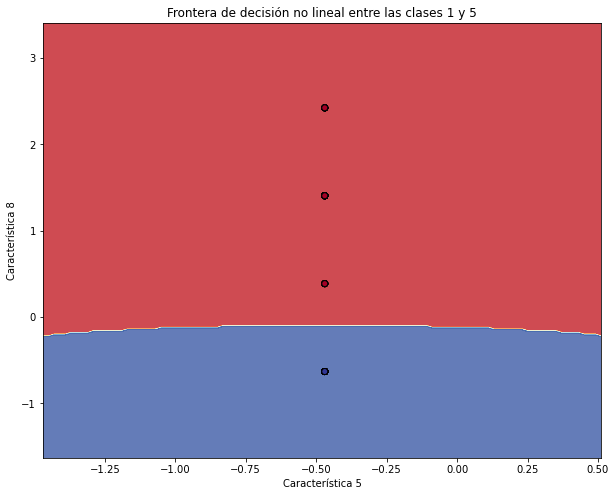

In [99]:

import matplotlib.pyplot as plt

#REPRESENTACION 2D

# Características (X) y etiquetas (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Dividir el conjunto de datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Seleccionar dos características específicas para visualizar
feature_1_index = 5
feature_2_index = 8

# Seleccionar las dos características del conjunto de entrenamiento
X_train_selected = X_train_scaled[:, [feature_1_index, feature_2_index]]

# Seleccionar las dos características del conjunto de prueba
X_test_selected = X_test_scaled[:, [feature_1_index, feature_2_index]]

# Seleccionar dos clases para visualizar (en este caso, del conjunto de entrenamiento)
class_1, class_2 = 1, 5
mask_train = (y_train == class_1) | (y_train == class_2)
X_subset_train = X_train_selected[mask_train]
y_subset_train = y_train[mask_train]

# Entrenar un nuevo modelo SVM con kernel RBF
svm_2d = SVC(kernel='rbf', random_state=42, gamma='scale')
svm_2d.fit(X_subset_train, y_subset_train)

# Crear una malla para visualizar la frontera de decisión
x_min, x_max = X_subset_train[:, 0].min() - 1, X_subset_train[:, 0].max() + 1
y_min, y_max = X_subset_train[:, 1].min() - 1, X_subset_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualizar la frontera de decisión
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(X_subset_train[:, 0], X_subset_train[:, 1], c=y_subset_train,
                      cmap=plt.cm.RdYlBu, edgecolor='black')
plt.xlabel(f'Característica {feature_1_index }')
plt.ylabel(f'Característica {feature_2_index }')
plt.title(f'Frontera de decisión no lineal entre las clases {class_1} y {class_2}')

plt.show()






